# Startup batch experiment (open pond, SI state + volume)

This notebook explains the **startup batch** path used by [`scripts/experiments/run_startup_batch_3day.py`](../scripts/experiments/run_startup_batch_3day.py): **Fig. 1 diel forcing**, **17 ALBA liquid states**, **variable pond volume** from evaporation (rain optional; default off in the script).

**Kernel:** use the project environment (`uv run python` / `.venv`) so `import bioprocess_twin` works.

**Horizon:** set **`STARTUP_DAYS`** in the simulation cell (e.g. `3` → **72** h of hourly samples; `10` → **240** h). Integration runs from clock **t = 0** to **t = STARTUP_DAYS × 24** h.

**Timing:** SciPy `solve_ivp` does not stream per-step progress. Adjust **`SOLVER_METHOD`**, **`RTOL` / `ATOL`**, and **`MAX_STEP`** in the parameters cell for exploration vs stricter accuracy.


## What the model integrates

- **Augmented state:** $\mathbf{z} = [\mathbf{y}, V]$ with $\mathbf{y}$ the **17-component SI** vector (`StateVector` layout) and $V$ pond volume [m³].
- **Water balance:** $\mathrm{d}V/\mathrm{d}t = Q_\mathrm{rain} - E$ from the schedule (`include_rain=False` → no rain term).
- **Concentrations:** biological RHS from `evaluate_liquid_ode_rhs` plus a **well-mixed dilution/concentration term** when $V$ changes.
- **Forcing:** `DielForcingSchedule(season=...)` supplies repeating **daily** $T(t)$, $I_0(t)$, evaporation (Fig. 1–style curves).
- **Initial condition:** `default_reasonable_startup_y0()` — nominal rich substrate + modest inoculum (not calibrated to Casagli et al.).


## Parameters you can change

| Symbol / name | Meaning |
|---------------|---------|
| `SEASON` | `spring` \| `summer` \| `autumn` \| `winter` — selects Fig. 1 curves |
| `VOLUME_M3` | Initial pond volume [m³] |
| `SURFACE_M2` | Surface area for rain/evaporation scaling [m²] |
| `INCLUDE_RAIN` | `False` matches the default CLI experiment script |
| `SOLVER_METHOD` | SciPy `solve_ivp` method (e.g. `LSODA`, `RK45`, `BDF`, `Radau`) |
| `RTOL`, `ATOL` | Relative and absolute integration tolerances |
| `MAX_STEP` | Maximum internal step [h]; set to `None` to omit (SciPy default: no cap) |

Integration metadata (`StartupIntegrationMetadata`) reports **wall time inside `solve_ivp`**, `nfev`, and an **indicative** average seconds per output sample (= solver wall time / number of CSV rows).


In [6]:
from __future__ import annotations

import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from bioprocess_twin.experiments import (
    SI_STATE_COLUMNS,
    hourly_t_eval_for_startup_days,
    trajectory_to_dataframe,
)
from bioprocess_twin.forcing import DielForcingSchedule, to_env_conditions
from bioprocess_twin.models.kinetic_parameters import default_alba
from bioprocess_twin.models.kinetics import EnvConditions
from bioprocess_twin.simulator import (
    LiquidOdeRhsProblem,
    StartupBatchProblem,
    default_reasonable_startup_y0,
    run_startup_batch,
)
from bioprocess_twin.simulator.beer_lambert import env_irradiance_umol_m2_s
from bioprocess_twin.simulator.liquid_rhs import evaluate_liquid_rhs, state_vector_from_y

try:
    from IPython.display import display
except ImportError:
    display = print  # noqa: A001

# --- pond / scenario (must match run_case / pH replay) ---
SEASON = "summer"
VOLUME_M3 = 17.0
SURFACE_M2 = 56.0
INCLUDE_RAIN = False

LIQUID_PROBLEM = LiquidOdeRhsProblem(schedule=DielForcingSchedule(season=SEASON))

# --- SciPy solve_ivp (passed through by run_case) ---
SOLVER_METHOD = "LSODA"
RTOL = 1e-1
ATOL = 1e-3
MAX_STEP = 2.0  # hours; use None to omit max_step


In [7]:
def run_case(
    startup_days: float,
    label: str,
    *,
    y0: np.ndarray | None = None,
    volume_m3_initial: float | None = None,
):
    """Run startup_batch; print progress and timing (same idea as the CLI script)."""
    print(f"\n=== {label}: startup_days={startup_days} ===", flush=True)
    print(
        "Simulation is running; this may take several minutes depending on horizon and hardware.",
        flush=True,
    )
    y_ic = default_reasonable_startup_y0() if y0 is None else np.asarray(y0, dtype=np.float64).ravel()
    if y_ic.size != 17:
        raise ValueError(f"y0 must have length 17 (SI), got {y_ic.size}")
    v_ic = float(VOLUME_M3 if volume_m3_initial is None else volume_m3_initial)
    cfg = StartupBatchProblem(
        problem=LIQUID_PROBLEM,
        startup_days=float(startup_days),
        y0=y_ic,
        volume_m3_initial=v_ic,
        surface_area_m2=SURFACE_M2,
        include_rain=INCLUDE_RAIN,
    )
    t_eval = hourly_t_eval_for_startup_days(float(startup_days))
    wall0 = time.perf_counter()
    ivp_kw: dict = dict(
        method=SOLVER_METHOD,
        rtol=RTOL,
        atol=ATOL,
        return_integration_metadata=True,
    )
    if MAX_STEP is not None:
        ivp_kw["max_step"] = MAX_STEP
    res, meta = run_startup_batch(cfg, t_eval_hours=t_eval, **ivp_kw)
    wall_total = time.perf_counter() - wall0
    n_out = max(meta.n_output_points, 1)
    est_per_row = meta.solver_wall_time_s / float(n_out)
    print(
        f"Finished. success={res.success} | "
        f"wall_total_s={wall_total:.3f} | solver_s={meta.solver_wall_time_s:.3f} | "
        f"n_output={meta.n_output_points} | nfev={meta.nfev} | "
        f"est_s_per_output_row={est_per_row:.6g} (indicative)",
        flush=True,
    )
    print(meta.message or "", flush=True)
    df = trajectory_to_dataframe(res.t_hours, res.y, res.volume_m3)
    return res, meta, df


def ph_series_for_trajectory(df: pd.DataFrame, problem: LiquidOdeRhsProblem) -> np.ndarray:
    """Re-evaluate Stage-6 charge balance to get simulated pH at each saved row (can be slow)."""
    th = df["t_hours"].to_numpy(dtype=np.float64)
    Y = df[list(SI_STATE_COLUMNS)].to_numpy(dtype=np.float64)
    # Match startup_batch RHS: solver samples may be slightly negative; StateVector requires >= 0.
    Y = np.maximum(Y, 0.0)
    ph = np.empty(th.shape[0], dtype=np.float64)
    params = problem.kinetic_parameters if problem.kinetic_parameters is not None else default_alba()
    for i in range(th.shape[0]):
        st = state_vector_from_y(Y[i])
        sample = problem.schedule.at(float(th[i]))
        if problem.mixed_layer_depth_m is not None:
            i_env = env_irradiance_umol_m2_s(
                surface_irradiance_umol_m2_s=float(sample.irradiance_umol_m2_s),
                epsilon_cod_m2_per_g=float(params.epsilon_light),
                x_alg_g_cod_m3=float(st.X_ALG),
                mixed_layer_depth_m=float(problem.mixed_layer_depth_m),
            )
            env = EnvConditions(
                temperature_C=float(sample.temperature_C),
                pH=float(problem.placeholder_ph_for_env),
                irradiance_umol_m2_s=float(i_env),
            )
        else:
            env = to_env_conditions(sample, ph=problem.placeholder_ph_for_env)
        out = evaluate_liquid_rhs(
            st,
            env,
            kinetic_parameters=problem.kinetic_parameters,
            theta_kla=problem.theta_kla,
            gas_conditions=problem.gas_conditions,
            delta_cat_an_mol_per_m3=problem.delta_cat_an_mol_per_m3,
            initial_ph=problem.initial_ph,
            options=problem.options,
            k_ref=problem.k_ref,
            dh=problem.dh,
        )
        ph[i] = float(out.ph_result.ph)
    return ph


## Simulation run

Set **`STARTUP_DAYS`** (calendar days simulated). Output grid is **hourly** from **t = 0** to **t = STARTUP_DAYS × 24** hours (e.g. **3** days → **72** h end time; **10** days → **240** h).


In [8]:
STARTUP_DAYS = 3.0  # e.g. 3 -> 72 h span; 10 -> 240 h span

_, _, df_full = run_case(STARTUP_DAYS, f"Startup batch ({STARTUP_DAYS} d)")
display(df_full.head())
display(df_full.tail())



=== Startup batch (3.0 d): startup_days=3.0 ===
Simulation is running; this may take several minutes depending on horizon and hardware.
Finished. success=True | wall_total_s=62.041 | solver_s=62.041 | n_output=73 | nfev=22209 | est_s_per_output_row=0.849872 (indicative)
The solver successfully reached the end of the integration interval.


,t_hours,volume_m3,X_ALG,X_AOB,X_NOB,X_H,X_S,X_I,S_S,S_I,S_IC,S_ND,S_NH,S_NO2,S_NO3,S_N2,S_PO4,S_O2,S_H2O
0,0.0,17.000000,50.000000,12.000000,6.000000,70.000000,140.000000,25.000000,220.000000,18.000000,40.000000,42.000000,14.000000,0.080000,4.000000,0.150000,15.000000,6.000000,0.000000
1,1.0,16.992692,49.970591,12.005161,6.002581,75.710869,138.504411,25.153176,210.561848,18.291504,11.117560,41.569867,15.044964,-0.095530,3.997857,0.328120,14.968566,6.037653,0.034327
2,2.0,16.986177,49.936674,12.009765,6.004883,82.083804,136.924817,25.317663,199.938264,18.601146,4.026043,41.107593,16.082493,-0.294603,3.997950,0.527355,14.931853,5.793491,0.070916
3,3.0,16.980056,49.899222,12.014095,6.007047,89.265484,135.258738,25.497131,187.852224,18.932702,2.221701,40.605526,17.113444,-0.530111,3.997874,0.763095,14.889286,5.438915,0.110397
4,4.0,16.974045,49.858845,12.018349,6.009175,97.405522,133.505769,25.695561,174.013461,19.289954,1.895527,40.053837,18.140235,-0.816571,3.997673,1.049874,14.840172,4.986010,0.153538


,t_hours,volume_m3,X_ALG,X_AOB,X_NOB,X_H,X_S,X_I,S_S,S_I,S_IC,S_ND,S_NH,S_NO2,S_NO3,S_N2,S_PO4,S_O2,S_H2O
68,68.0,15.538037,50.869346,20.328630,7.042238,53.824524,42.807263,57.631289,0.697811,57.982037,0.590001,-0.000051,54.850677,0.332273,33.988432,27.018059,17.942481,6.879124,3.463789
69,69.0,15.524398,50.821516,20.381169,7.057177,52.891235,42.176456,57.874949,0.683256,58.273545,0.578761,-0.000051,55.326472,0.331098,34.358532,27.081354,17.974264,7.054086,3.470569
70,70.0,15.513229,50.761719,20.436427,7.072456,51.981454,41.525879,58.104675,0.669484,58.552846,0.580479,-0.000051,55.740935,0.328638,34.772363,27.139784,18.002738,7.100247,3.476962
71,71.0,15.503966,50.693312,20.493289,7.087749,51.108659,40.864764,58.320035,0.656221,58.819002,0.598605,-0.000051,56.114732,0.326384,35.207709,27.193498,18.028390,7.010625,3.483028
72,72.0,15.495774,50.623622,20.546336,7.101800,50.301185,40.214432,58.518422,0.643770,59.068091,0.591443,-0.000051,56.530414,0.322846,35.604669,27.242888,18.051863,7.120110,3.488768


## Overview: DO, pH, Fig. 1 forcing, volume

**Left/right:** dissolved oxygen (state) and **pH** recomputed from the same Stage-6 chemistry as the RHS (charge balance; may take time on long trajectories).

**Middle:** environmental **inputs** from `DielForcingSchedule` (temperature, surface irradiance, evaporation rate) evaluated at each output time — same season as **`SEASON`**.

**Last:** pond **volume** vs time (evaporation shrinks \(V\)); concentrations alone can be misleading without this context.


Computing pH along trajectory (slow if many rows)...


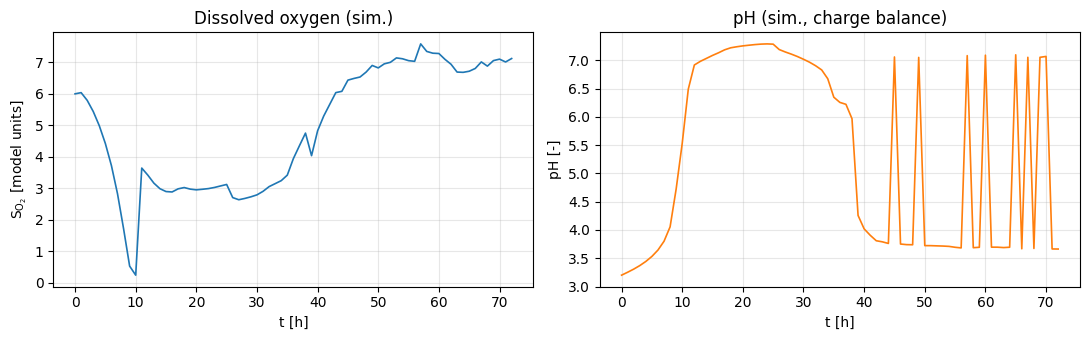

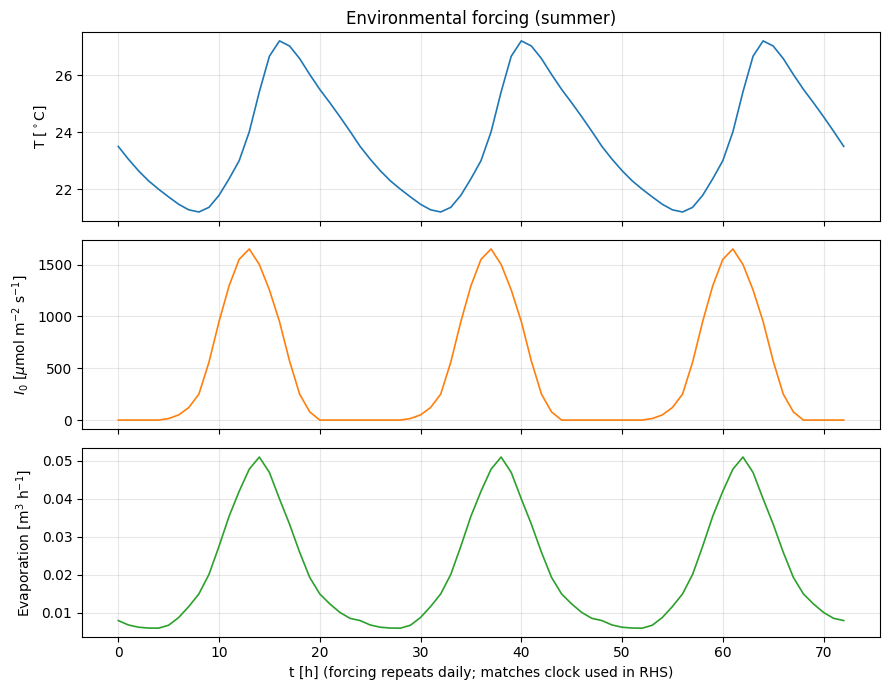

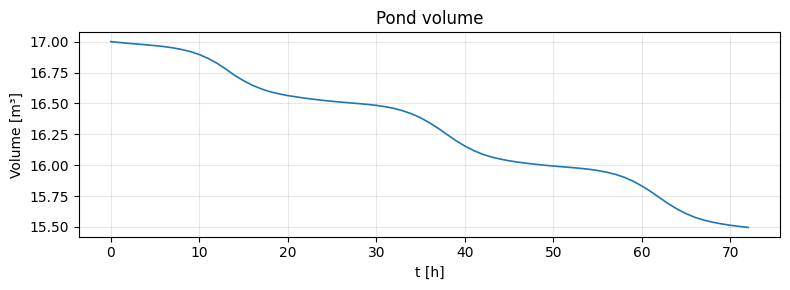

In [9]:
th = df_full["t_hours"].to_numpy(dtype=np.float64)
fa = LIQUID_PROBLEM.schedule.at_many(th)

print("Computing pH along trajectory (slow if many rows)...", flush=True)
ph_arr = ph_series_for_trajectory(df_full, LIQUID_PROBLEM)

# --- Paper-style: DO | pH ---
fig, (ax_do, ax_ph) = plt.subplots(1, 2, figsize=(11, 3.5), sharex=True)
ax_do.plot(th, df_full["S_O2"].to_numpy(), color="C0", linewidth=1.2)
ax_do.set_ylabel(r"S$_{\mathrm{O_2}}$ [model units]")
ax_do.set_title("Dissolved oxygen (sim.)")
ax_do.grid(True, alpha=0.3)
ax_ph.plot(th, ph_arr, color="C1", linewidth=1.2)
ax_ph.set_ylabel("pH [-]")
ax_ph.set_title("pH (sim., charge balance)")
ax_ph.grid(True, alpha=0.3)
ax_ph.set_xlabel("t [h]")
ax_do.set_xlabel("t [h]")
plt.tight_layout()
plt.show()

# --- Casagli Fig. 1 style drivers (same clock as integration) ---
fig2, axes = plt.subplots(3, 1, sharex=True, figsize=(9, 7))
axes[0].plot(fa.t_hours, fa.temperature_C, color="C0", linewidth=1.2)
axes[0].set_ylabel(r"T [$^\circ$C]")
axes[0].set_title(f"Environmental forcing ({SEASON})")
axes[1].plot(fa.t_hours, fa.irradiance_umol_m2_s, color="C1", linewidth=1.2)
axes[1].set_ylabel(r"$I_0$ [$\mu$mol m$^{-2}$ s$^{-1}$]")
axes[2].plot(fa.t_hours, fa.evaporation_m3_h, color="C2", linewidth=1.2)
axes[2].set_ylabel(r"Evaporation [m$^3$ h$^{-1}$]")
axes[2].set_xlabel("t [h] (forcing repeats daily; matches clock used in RHS)")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Volume ---
fig3, axv = plt.subplots(figsize=(8, 3))
axv.plot(th, df_full["volume_m3"].to_numpy(), color="C0", linewidth=1.2)
axv.set_xlabel("t [h]")
axv.set_ylabel("Volume [m³]")
axv.set_title("Pond volume")
axv.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Optional: species trajectory plots

Requires `matplotlib`. Each cell uses **`df_full`** from the simulation above (re-run after changing **`STARTUP_DAYS`** or solver settings).

Each plotting cell uses **two panels**: **concentration** and **inventory** \(C \times V\) in the pond.


## Plots: particulate biomass

`X_ALG`, `X_AOB`, `X_NOB`, `X_H`: **top** = concentration in liquid; **bottom** = \(C \times V\) (inventory in pond). Uses `df_full`.


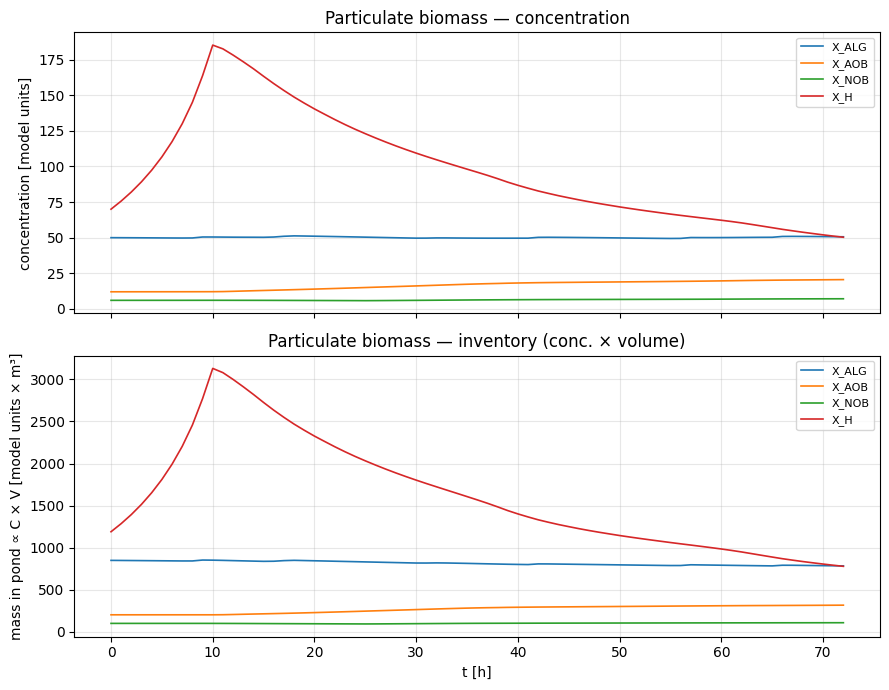

In [10]:
V = df_full["volume_m3"]
fig, (ax_c, ax_m) = plt.subplots(2, 1, sharex=True, figsize=(9, 7))
for col in ("X_ALG", "X_AOB", "X_NOB", "X_H"):
    ax_c.plot(df_full["t_hours"], df_full[col], label=col, linewidth=1.2)
    ax_m.plot(df_full["t_hours"], df_full[col] * V, label=col, linewidth=1.2)
ax_c.set_ylabel("concentration [model units]")
ax_c.set_title("Particulate biomass — concentration")
ax_c.legend(loc="best", fontsize=8)
ax_c.grid(True, alpha=0.3)
ax_m.set_xlabel("t [h]")
ax_m.set_ylabel("mass in pond ∝ C × V [model units × m³]")
ax_m.set_title("Particulate biomass — inventory (conc. × volume)")
ax_m.legend(loc="best", fontsize=8)
ax_m.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Plots: dissolved nitrogen species

`S_NH`, `S_NO2`, `S_NO3`, `S_N2`: **top** = concentration; **bottom** = \(C \times V\). (`df_full`)


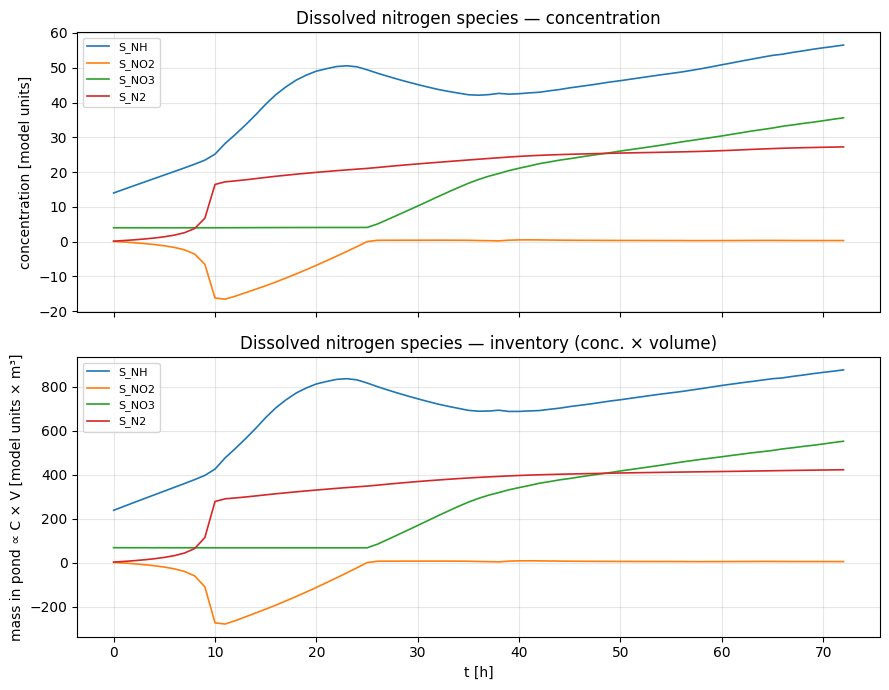

In [11]:
V = df_full["volume_m3"]
fig, (ax_c, ax_m) = plt.subplots(2, 1, sharex=True, figsize=(9, 7))
for col in ("S_NH", "S_NO2", "S_NO3", "S_N2"):
    ax_c.plot(df_full["t_hours"], df_full[col], label=col, linewidth=1.2)
    ax_m.plot(df_full["t_hours"], df_full[col] * V, label=col, linewidth=1.2)
ax_c.set_ylabel("concentration [model units]")
ax_c.set_title("Dissolved nitrogen species — concentration")
ax_c.legend(loc="best", fontsize=8)
ax_c.grid(True, alpha=0.3)
ax_m.set_xlabel("t [h]")
ax_m.set_ylabel("mass in pond ∝ C × V [model units × m³]")
ax_m.set_title("Dissolved nitrogen species — inventory (conc. × volume)")
ax_m.legend(loc="best", fontsize=8)
ax_m.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Plot: phosphate

`S_PO4`: **top** = concentration; **bottom** = \(C \times V\). (`df_full`)


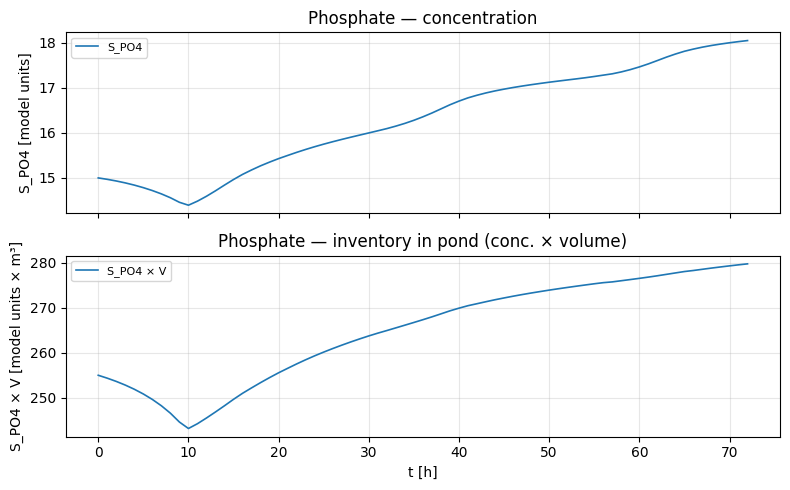

In [12]:
V = df_full["volume_m3"]
fig, (ax_c, ax_m) = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
ax_c.plot(df_full["t_hours"], df_full["S_PO4"], color="C0", linewidth=1.2, label="S_PO4")
ax_c.set_ylabel("S_PO4 [model units]")
ax_c.set_title("Phosphate — concentration")
ax_c.legend(loc="best", fontsize=8)
ax_c.grid(True, alpha=0.3)
ax_m.plot(df_full["t_hours"], df_full["S_PO4"] * V, color="C0", linewidth=1.2, label="S_PO4 × V")
ax_m.set_xlabel("t [h]")
ax_m.set_ylabel("S_PO4 × V [model units × m³]")
ax_m.set_title("Phosphate — inventory in pond (conc. × volume)")
ax_m.legend(loc="best", fontsize=8)
ax_m.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
